In [1]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_token = user_secrets.get_secret("pfn_key")

RUN_LOCAL_MODEL = False
USE_PFN_TOKEN   = False

if RUN_LOCAL_MODEL:
    print("Loading tabpfn_local... ", end='')
    try:
        from tabpfn import TabPFNClassifier
    except:
        %pip install -q -U tabpfn
        from tabpfn import TabPFNClassifier
    ## -----------------------------------------------------
    if USE_PFN_TOKEN: # Option 1: Use secret token key
        os.environ["TABPFN_TOKEN"] = secret_token
    else: # Option 2: Access to direct model
        os.environ["TABPFN_MODEL_CACHE_DIR"] = "/kaggle/input/models/prior-labsai/tabpfn-3/pytorch/default/1"
    print("Complete!")
else:
    print("Connecting tabpfn_client... ", end='')
    try:
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token
    except:
        %pip install -q -U tabpfn-client
        import tabpfn_client
        from tabpfn_client import TabPFNClassifier, set_access_token

    tabpfn_client.set_access_token(secret_token)
    print("Complete!")

secret_token

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 912.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32

'tabpfn_sk_BRazYGiNBKYBWNHuuOmOJUvMiqzHsLQLlPrRQMsBQ8Q'

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, log_loss, RocCurveDisplay
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder, label_binarize

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [6]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [7]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


In [8]:
n_unique = train[BASE].nunique().sort_values()
n_unique

diet_type                      3
physical_activity_level        3
sleep_quality                  3
gender                         3
smoking_alcohol                3
stress_level                   3
water_intake                 400
heart_rate                   537
sleep_duration               701
exercise_duration            856
bmi                         1596
calorie_expenditure         2101
step_count                 12807
dtype: int64

In [9]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    wts = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return wts

def get_sample_weights(y, y_true):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    """
    cls = np.unique(y_true)
    wts = compute_class_weight('balanced', classes=cls, y=y_true)
    class_weights = dict(zip(cls, wts))
    return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [10]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [11]:
# for col in ['delta']:
#     print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in range(-3, 4):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nCreating quantile-based Q_BINS... ", end='')
#     for q in [100]:
#         q_n = f'{col}_qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [12]:
# for col in ['RaceProgress']:
#     # print(f"\nRounding... ", end='')
#     # for r in [-2, -1, 0, 1, 2]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(5):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [10]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [14]:
# train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

In [15]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [16]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS + ['LapNumber', 'RaceProgress']: # 'Position_Change'
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")

In [17]:
# ## -- Arithmetic interaction --
# # u - g, g - r, r - i, i - z

# # ('u', 'g'),
# # ('g', 'r'),
# # ('i', 'z'),
# # ('g', 'i'),
# # ('r', 'z')

# for df in tqdm([train, test, orig]):
#     df['u_g_sub_'] = df['u'] - df['g']
#     df['g_r_sub_'] = df['g'] - df['r']

#     df['g_i_sub_'] = df['g'] - df['i']
#     df['r_z_sub_'] = df['r'] - df['z']

#     df['i_z_sub_'] = df['i'] - df['z']
#     df['r_i_sub_'] = df['r'] - df['i']
    
#     df['stellar_locus_dist'] = np.sqrt((df['g_r_sub_'] - 0.52)**2 + (df['r_i_sub_'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"_{band}_redshift_div_"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

# color_bands = [c for c in train.columns if c.endswith('_sub_') or c.endswith('_div_')]
# color_bands.append('stellar_locus_dist')

# train[color_bands].describe()

In [18]:
# ## -- Cyclical extraction --
# for df in [train, test, orig]:
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in [train, test, orig]:
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [19]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# INTER

In [20]:
# sleep(2); gc.collect()

In [21]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
# train, test, _, orig_cols = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=n_unique.index[:10].tolist(),
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(f"Original features merged: {len(orig_cols)}")

In [25]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []
# nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')
#     orig[n]  = __[len(train)+len(test):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [26]:
# ## -- Factorize combined data --
# for c in CATS:
#     combined = pd.concat([train[c], test[c], orig[c]])
#     combined = combined.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combined[:len(train)]
#     test[c]  = combined[len(train):len(train)+len(test)]
#     orig[c]  = combined[-len(orig):]

# print('Label encoding complete!')

In [27]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 13


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


# ML TRAINING

In [28]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold,
    cat_cols=None, use_orig=False):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    X = train_df[features]
    y = train_df[target]

    num_cls = y.nunique()
    
    oof_preds   = np.zeros((len(X), num_cls))
    test_preds  = np.zeros((len(test_df), num_cls))
    fold_scores = []
    brier_scores = []

    if 'group_kf' in model_name:
        print("Using GROUP splits --- ")
        strat_id = y.astype(str) + '__' + X['Year'].astype(str)
        splitter = kfold.split(X, strat_id)
    else:
        print("Using REGULAR splits --- ")
        splitter = kfold.split(X, y)

    for idx, (train_idx, val_idx) in enumerate(splitter, 1):
        print(f"\n***** FOLD {idx}/{kfold.n_splits} | ", end='')

        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        ## -- OPTION A: Concatenate orginal data --
        if use_orig:
            X_train = pd.concat([X_train, orig[features]], ignore_index=True)
            y_train = pd.concat([y_train, orig[target]], ignore_index=True)
            # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # cme_cols = ROUNDS
        # print(f"CategoryMeanEncoding: {len(cme_cols)} | ", end='')
        # cme = CategoryMeanTransformer(cat_cols=cme_cols)
        # X_train = cme.fit_transform(X_train, y_train)
        # X_valid = cme.transform(X_valid)
        # X_test  = cme.transform(X_test)

        # te_enc  = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cat_cols:
        #     combined[c] = combined[c].astype(str)
        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"X_train: {X_train.shape} *****")

        cat_idx = [[*X_train.columns].index(f) for f in cat_cols]
        print(cat_idx)
    
        model = TabPFNClassifier(**params, categorical_features_indices=cat_idx)
        model.fit(X_train, y_train)

        ## -- Predictions --
        oof_preds[val_idx] = model.predict_proba(X_valid)

        ## -- Split test to avoid prediction limit 200k
        part_1_preds = model.predict_proba(X_test[:150_000])
        part_2_preds = model.predict_proba(X_test[150_000:])

        test_preds += np.vstack((part_1_preds, part_2_preds))

        ## -- Calculate fold scores --
        fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
        brier_score = multi_class_brier(y_valid, oof_preds[val_idx], [*mapping.values()])
        fold_scores.append(fold_score); brier_scores.append(brier_score)

        print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

        ## -- Clean up memory --
        torch.cuda.empty_cache()

    ## -- Average test predictions --
    test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'scores': oof_score,
        'model': model,
        'val_data': X_valid,
    }

print('⚙️ Trainer function ready ⚙️')

⚙️ Trainer function ready ⚙️


In [29]:
all_predictions = {}

MULTI_SEEDS = [CFG['SEED'], 777, 1234, 24611, 0]
ALL_CATS = CATS

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])
skf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [30]:
USE_FULL_TRAIN = False
USE_CALIBATOR  = False

x_sample, x_sample2 = train_test_split(train, train_size=0.35, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
84979,84979,2,4.92,79.1,23.02,1762.0,1792.0,27.5,1.89,non-veg,high,poor,sedentary,no,other
466605,466605,1,7.95,67.4,22.38,2201.0,2352.0,14.1,2.84,veg,medium,good,sedentary,no,male
498625,498625,1,7.73,82.8,19.96,2258.0,5987.0,0.3,2.49,non-veg,low,poor,sedentary,occasional,other
212443,212443,1,6.81,88.0,24.73,NaN,2558.0,41.2,1.27,veg,low,good,sedentary,yes,male
103754,103754,1,8.24,85.0,22.83,1562.0,4896.0,24.2,2.41,non-veg,medium,poor,sedentary,occasional,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232046,232046,2,4.65,67.5,25.50,2547.0,9185.0,56.0,1.59,veg,high,poor,moderate,occasional,female
176610,176610,1,7.24,79.0,23.77,2484.0,7838.0,33.9,2.22,veg,low,good,sedentary,yes,male
290521,290521,1,7.13,84.8,22.35,2060.0,14613.0,37.8,1.90,veg,high,average,active,no,male
596234,596234,1,NaN,64.1,NaN,2234.0,11180.0,63.6,2.14,veg,medium,good,active,yes,male


In [31]:
# !rm -r /kaggle/working

### Balancing for Balanced Metrics

Setting `balance_probabilities=True` is a simple heuristic for imbalanced data when your evaluation metric weights each class equally regardless of its frequency (e.g. `balanced accuracy`, `balanced log loss`). It re-weights the output probabilities based on the class frequencies in the training data.


This is a simpler, non-optimized alternative to `eval_metric="balanced_accuracy"` with `tune_decision_thresholds=True`.


In [32]:
local_params = {
    'n_estimators': 4,
    'inference_config': {'SUBSAMPLE_SAMPLES': 50_000}, # Subsample at inference
    'ignore_pretraining_limits': True, # Ignore 100k limit
    'random_state': CFG['SEED'],
    # ---------------------------------------------------------------------------
    'device': ['cuda:0', 'cuda:1'], # 'auto'
    'fit_mode': 'fit_with_cache',
    'eval_metric': 'balanced_accuracy',
    'balance_probabilities': True,
    'tuning_config': {'tune_decision_thresholds': True}, ## f1, accuracy
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, ## loss, brier
    # ---------------------------------------------------------------------------
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

client_params = {
    # ------ thinking_mode limited to 200k train data
    'thinking_mode': True,
    'thinking_effort': 'high',
    'thinking_metric': 'accuracy',
    # -----------------------------------------------
    'n_estimators': 4,
    'inference_config': {'SUBSAMPLE_SAMPLES': 50_000}, # Subsample at inference
    'ignore_pretraining_limits': True, # Ignore 100k limit
    'balance_probabilities': True,
    'random_state': CFG['SEED'],
    # 'tuning_config': {"tune_decision_thresholds": True, "calibrate_temperature": True}, ## loss, brier
    # 'softmax_temperature': 0.9,
    # 'average_before_softmax': False,
    # 'inference_precision': 'auto',
    # 'memory_saving_mode': 'auto',
    # 'n_preprocessing_jobs': 96,
    # 'differentiable_input': False,
}

n = 'tabpfn' if RUN_LOCAL_MODEL else 'tabpfn_client_200k'

# for VALUE in [4, 6, 8]:
#     PARAMS['n_estimators'] = VALUE
#     n = f"{VERS}_{str(VALUE)}"
all_predictions[n] = Trainer_CV(
    model_name=n,
    params=local_params if RUN_LOCAL_MODEL else client_params,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kfold=skf,
    use_orig=False,
    cat_cols=CATS,
)


===== Starting CV: tabpfn_client_200k =====
Using REGULAR splits --- 

***** FOLD 1/5 | X_train: (193224, 13) *****
[7, 8, 9, 10, 11, 12]
02:15 Fitting... Done!
00:15 Predicting... Done!
00:25 Predicting... Done!
00:24 Predicting... Done!
Fold 1 acc: 0.95130 | brier: 0.08498

***** FOLD 2/5 | X_train: (193224, 13) *****
[7, 8, 9, 10, 11, 12]
07:06 Fitting... Done!
00:51 Predicting... Done!
01:43 Predicting... Done!
01:39 Predicting... Done!
Fold 2 acc: 0.95102 | brier: 0.09051

***** FOLD 3/5 | X_train: (193224, 13) *****
[7, 8, 9, 10, 11, 12]
07:06 Fitting... Done!
00:54 Predicting... Done!
01:43 Predicting... Done!
01:43 Predicting... Done!
Fold 3 acc: 0.94784 | brier: 0.08820

***** FOLD 4/5 | X_train: (193224, 13) *****
[7, 8, 9, 10, 11, 12]
04:43 Fitting... Done!
00:39 Predicting... Done!
01:17 Predicting... Done!
01:15 Predicting... Done!
Fold 4 acc: 0.95060 | brier: 0.09113

***** FOLD 5/5 | X_train: (193224, 13) *****
[7, 8, 9, 10, 11, 12]
07:11 Fitting... Done!
00:53 Predicti

In [33]:
# ==================================================
# 5-FOLD CV: tabpfn
# ==================================================
#  • Fold 1 score: 0.94625 | brier: 0.09795
#  • Fold 2 score: 0.95035 | brier: 0.09855
#  • Fold 3 score: 0.95145 | brier: 0.08916
#  • Fold 4 score: 0.94934 | brier: 0.09153
#  • Fold 5 score: 0.94595 | brier: 0.08813
# -------------------------------------------------|
# OOF score: 0.94867
# AVG score: 0.94867 ± 0.00220
# -------------------------------------------------|
# OOF brier: 0.09306
# AVG brier: 0.09306 ± 0.00438
# -------------------------------------------------|
# 19.00 mins

# ==================================================
# 5-FOLD CV: tabpfn_client
# ==================================================
#  • Fold 1 score: 0.94806 | brier: 0.08949
#  • Fold 2 score: 0.95163 | brier: 0.08711
#  • Fold 3 score: 0.95218 | brier: 0.08143
#  • Fold 4 score: 0.95175 | brier: 0.08860
#  • Fold 5 score: 0.94876 | brier: 0.08905
# -------------------------------------------------|
# OOF score: 0.95047
# AVG score: 0.95047 ± 0.00171
# -------------------------------------------------|
# OOF brier: 0.08713
# AVG brier: 0.08713 ± 0.00296
# -------------------------------------------------|
# 34.16 mins

In [34]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == 'scores':
            all_scores[k] = y

all_scores

# plt.figure(figsize=(16, 6))
# ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_scores)), all_scores.values(), alpha=0.1)
# ax.set_title('Models scores', fontweight='semibold')
# ax.tick_params('x', rotation=30)
# # ax.set_ylim(0.95, 0.955)

# for i, s in enumerate(all_scores.values()):
#     ax.text(float(i), s+1e-4, s, ha='center', va='baseline')

# plt.tight_layout()
# plt.show()

{'tabpfn_client_200k': np.float64(0.94899)}

tabpfn_client_200k_94899 saved!


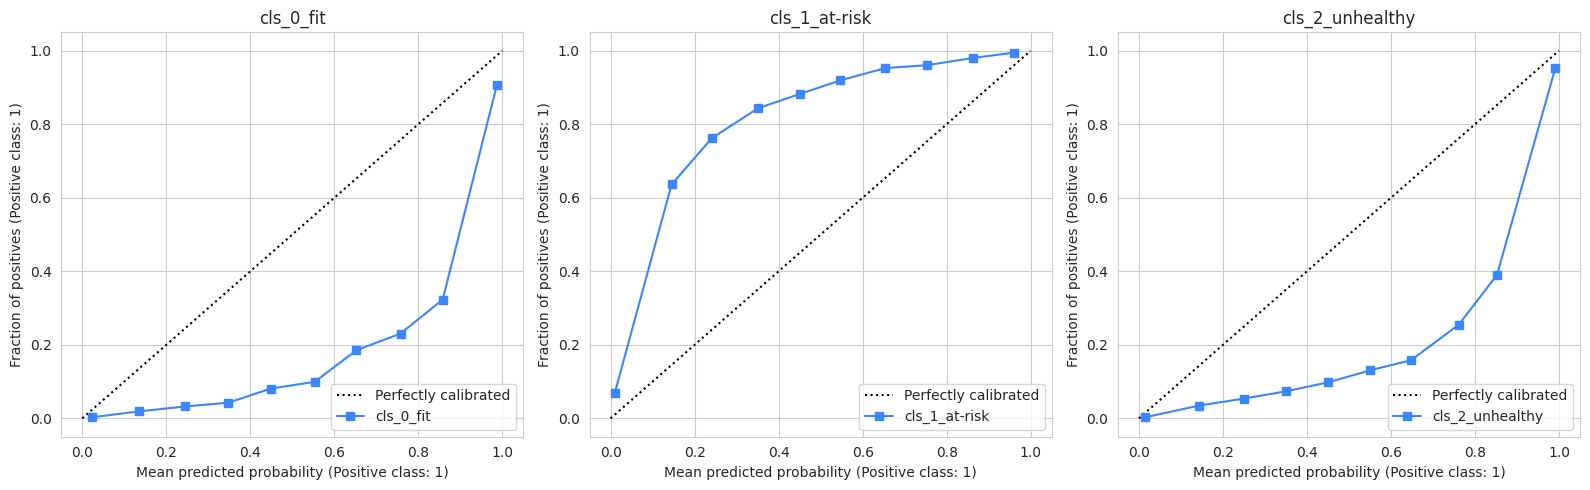

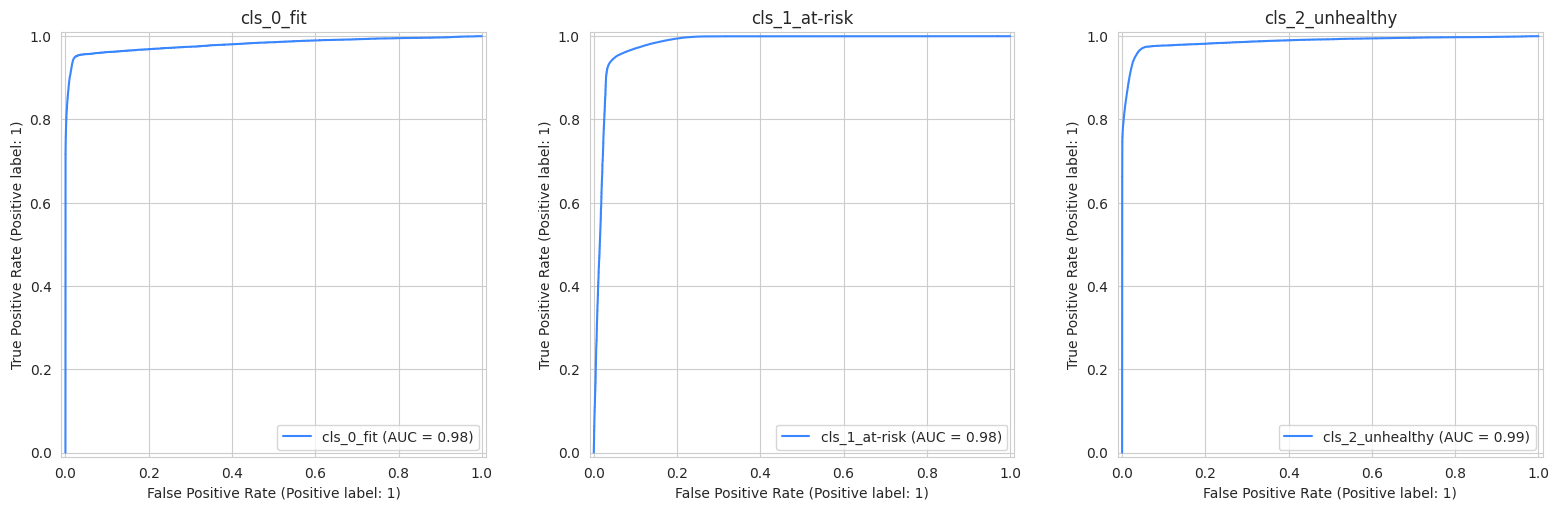

In [35]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            y_labels = pd.Series(np.argmax(y, axis=1))
            classes = [*mapping.keys()]
            name0 = f"cls_0_{classes[0]}"
            name1 = f"cls_1_{classes[1]}"
            name2 = f"cls_2_{classes[2]}"

            y_cls_0 = (train_data[TARGET] == 0).astype(int)
            y_cls_1 = (train_data[TARGET] == 1).astype(int)
            y_cls_2 = (train_data[TARGET] == 2).astype(int)
            p_cls_0 = y[:, 0]
            p_cls_1 = y[:, 1]
            p_cls_2 = y[:, 2]

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            CalibrationDisplay.from_predictions(y_cls_0, p_cls_0, n_bins=10, name=name0, ax=axs[0])
            CalibrationDisplay.from_predictions(y_cls_1, p_cls_1, n_bins=10, name=name1, ax=axs[1])
            CalibrationDisplay.from_predictions(y_cls_2, p_cls_2, n_bins=10, name=name2, ax=axs[2])
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            RocCurveDisplay.from_predictions(
                y_cls_0, p_cls_0, name=name0, ax=axs[0],
                sample_weight=get_sample_weights(y_cls_0, y_cls_0),
            )
            RocCurveDisplay.from_predictions(
                y_cls_1, p_cls_1, name=name1, ax=axs[1],
                sample_weight=get_sample_weights(y_cls_1, y_cls_1),
            )
            RocCurveDisplay.from_predictions(
                y_cls_2, p_cls_2, name=name2, ax=axs[2],
                sample_weight=get_sample_weights(y_cls_2, y_cls_2),
            )
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            print()

tabpfn_client_200k_94899 saved! (295753, 3)


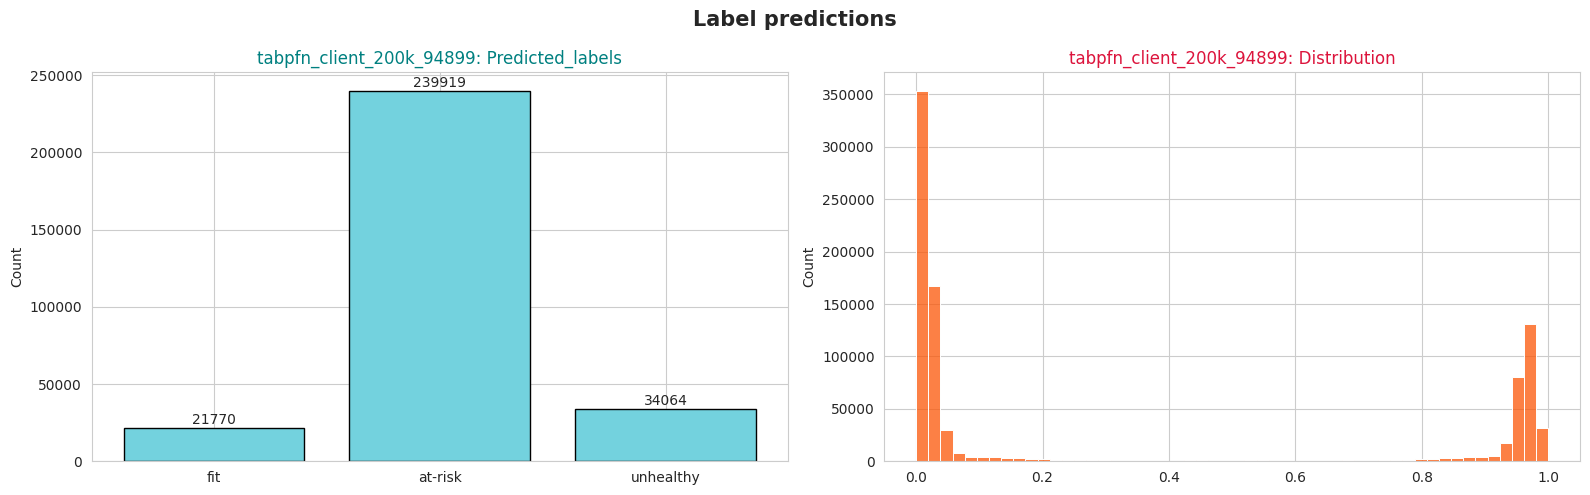

In [36]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"test_{n}_.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(16, 5))

            counts = [np.sum(y_labels == _) for _ in range(len(mapping))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')

            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')

            plt.tight_layout()
            plt.show()

            print()

In [37]:
pd.DataFrame(model_results)

,tabpfn_client_200k_94899
0,unhealthy
1,unhealthy
2,at-risk
3,at-risk
4,unhealthy
...,...
295748,fit
295749,at-risk
295750,unhealthy
295751,at-risk
